In [ ]:
# ============================================
# CELL 1 — INSTALL LIBRARIES
# ============================================

!pip install xgboost opencv-python kagglehub tensorflow -q

In [ ]:
# ============================================
# CELL 2 — IMPORT LIBRARIES
# ============================================

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

In [ ]:
# ============================================
# CELL 3 — RANDOM SEED
# ============================================

np.random.seed(42)

tf.random.set_seed(42)

os.makedirs("outputs", exist_ok=True)

In [ ]:
# ============================================
# CELL 4 — DOWNLOAD DATASET
# ============================================

path = kagglehub.dataset_download(
    "sartajbhuvaji/brain-tumor-classification-mri"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Dataset Path: /kaggle/input/brain-tumor-classification-mri


In [ ]:
# ============================================
# CELL 5 — DEFINE CLASSES
# ============================================

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

In [ ]:
# ============================================
# CELL 6 — LOAD RGB IMAGES
# ============================================

IMG_SIZE = 224

train_path = os.path.join(path, "Training")

print("Loading RGB Images...")

X_raw = []
Y = []

for cls, label in classes.items():

    class_path = os.path.join(train_path, cls)

    for filename in os.listdir(class_path):

        img_path = os.path.join(class_path, filename)

        img = cv2.imread(img_path)

        if img is not None:

            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            X_raw.append(img)

            Y.append(label)

X_raw = np.array(
    X_raw,
    dtype=np.float32
)

Y = np.array(Y)

print("RGB Dataset Shape :", X_raw.shape)

print("Labels Shape :", Y.shape)

Loading RGB Images...
RGB Dataset Shape : (2870, 224, 224, 3)
Labels Shape : (2870,)


In [ ]:
# ============================================
# CELL 7 — BUILD VGG16 FEATURE EXTRACTOR
# ============================================

print("Building VGG16 Feature Extractor...")

base_vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_vgg.trainable = False

gap_output = tf.keras.layers.GlobalAveragePooling2D()(
    base_vgg.output
)

extractor = Model(
    inputs=base_vgg.input,
    outputs=gap_output
)

extractor.summary()

Building VGG16 Feature Extractor...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# ============================================
# CELL 8 — EXTRACT VGG16 FEATURES
# ============================================

BATCH = 32

X_preprocessed = preprocess_input(
    X_raw.copy()
)

features = []

for i in range(0, len(X_preprocessed), BATCH):

    batch_features = extractor.predict(
        X_preprocessed[i:i+BATCH],
        verbose=0
    )

    features.append(batch_features)

    if (i // BATCH) % 10 == 0:

        print(
            f"Extracted {min(i+BATCH, len(X_preprocessed))}/{len(X_preprocessed)}"
        )

X_feats = np.vstack(features)

print("Feature Shape :", X_feats.shape)

Extracted 32/2870
Extracted 352/2870
Extracted 672/2870
Extracted 992/2870
Extracted 1312/2870
Extracted 1632/2870
Extracted 1952/2870
Extracted 2272/2870
Extracted 2592/2870
Feature Shape : (2870, 512)


In [ ]:
# ============================================
# CELL 9 — DATA SPLITS
# ============================================

splits = [
    (0.2, 0.8),
    (0.4, 0.6),
    (0.6, 0.4),
    (0.8, 0.2)
]


TRAIN : 20%
TEST  : 80%

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.8432055749128919
F1 Score          : 0.8433494724250266

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.90      0.81      0.85       316
 Pituitary Tumor       0.87      0.94      0.91       662
    Glioma Tumor       0.89      0.82      0.85       661
Meningioma Tumor       0.75      0.79      0.77       657

        accuracy                           0.84      2296
       macro avg       0.85      0.84      0.84      2296
    weighted avg       0.85      0.84      0.84      2296



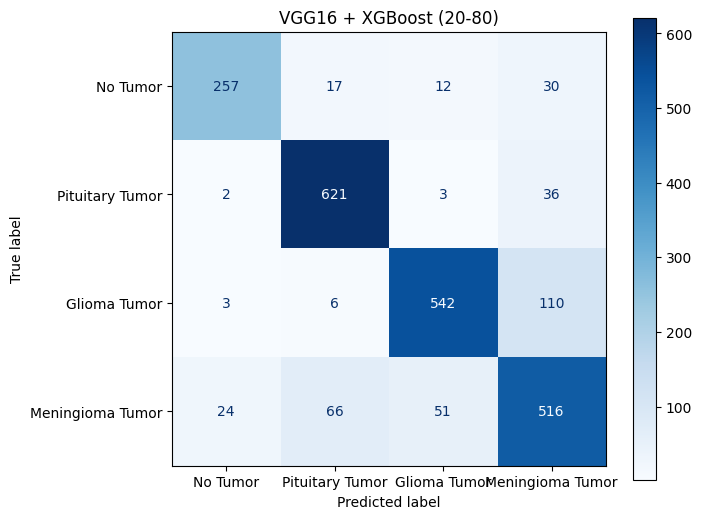


TRAIN : 40%
TEST  : 60%

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.8646922183507549
F1 Score          : 0.8647765258839349

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.94      0.85      0.89       237
 Pituitary Tumor       0.91      0.95      0.93       496
    Glioma Tumor       0.88      0.85      0.87       496
Meningioma Tumor       0.78      0.80      0.79       493

        accuracy                           0.86      1722
       macro avg       0.88      0.86      0.87      1722
    weighted avg       0.87      0.86      0.86      1722



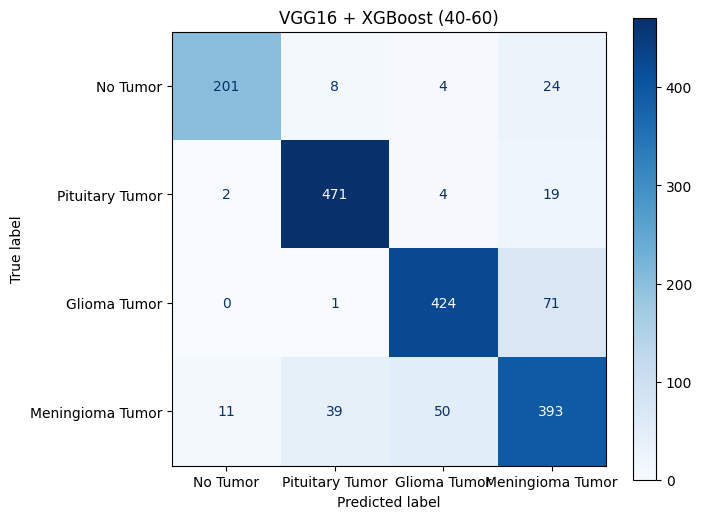


TRAIN : 60%
TEST  : 40%

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.8815331010452961
F1 Score          : 0.8821472642902188

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.95      0.87      0.91       158
 Pituitary Tumor       0.91      0.94      0.93       331
    Glioma Tumor       0.92      0.86      0.89       330
Meningioma Tumor       0.79      0.84      0.82       329

        accuracy                           0.88      1148
       macro avg       0.89      0.88      0.89      1148
    weighted avg       0.88      0.88      0.88      1148



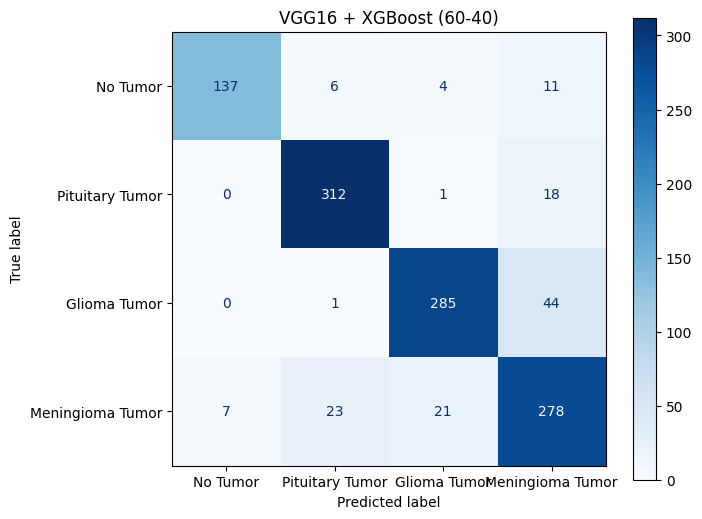


TRAIN : 80%
TEST  : 20%

Training VGG16 + XGBoost...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.8850174216027874
F1 Score          : 0.886439732380614

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.99      0.89      0.93        79
 Pituitary Tumor       0.94      0.93      0.94       166
    Glioma Tumor       0.90      0.84      0.87       165
Meningioma Tumor       0.78      0.88      0.83       164

        accuracy                           0.89       574
       macro avg       0.90      0.89      0.89       574
    weighted avg       0.89      0.89      0.89       574



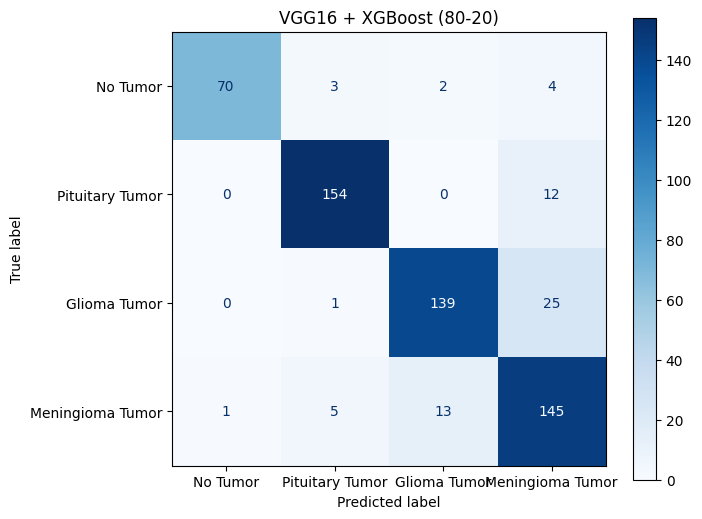

In [ ]:
# ============================================
# CELL 10 — VGG16 + XGBOOST TRAINING
# ============================================

vgg_train_acc = []

vgg_test_acc = []

vgg_f1 = []

labels = []

for train_ratio, test_ratio in splits:

    print("\n====================================")

    print(f"TRAIN : {int(train_ratio*100)}%")

    print(f"TEST  : {int(test_ratio*100)}%")

    print("====================================")

    # TRAIN TEST SPLIT
    xtrain_v, xtest_v, ytrain_v, ytest_v = train_test_split(
        X_feats,
        Y,
        train_size=train_ratio,
        test_size=test_ratio,
        random_state=42,
        stratify=Y
    )

    # XGBOOST MODEL
    xgb_vgg = XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining VGG16 + XGBoost...")

    xgb_vgg.fit(
        xtrain_v,
        ytrain_v
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb_vgg.predict(xtrain_v)

    test_pred = xgb_vgg.predict(xtest_v)

    # METRICS
    train_acc = accuracy_score(
        ytrain_v,
        train_pred
    )

    test_acc = accuracy_score(
        ytest_v,
        test_pred
    )

    f1 = f1_score(
        ytest_v,
        test_pred,
        average='weighted'
    )

    print("Training Accuracy :", train_acc)

    print("Testing Accuracy  :", test_acc)

    print("F1 Score          :", f1)

    vgg_train_acc.append(train_acc)

    vgg_test_acc.append(test_acc)

    vgg_f1.append(f1)

    labels.append(
        f"{int(train_ratio*100)}-{int(test_ratio*100)}"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            ytest_v,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(
        ytest_v,
        test_pred
    )

    fig, ax = plt.subplots(figsize=(7,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=True
    )

    plt.title(
        f"VGG16 + XGBoost ({int(train_ratio*100)}-{int(test_ratio*100)})"
    )

    plt.show()

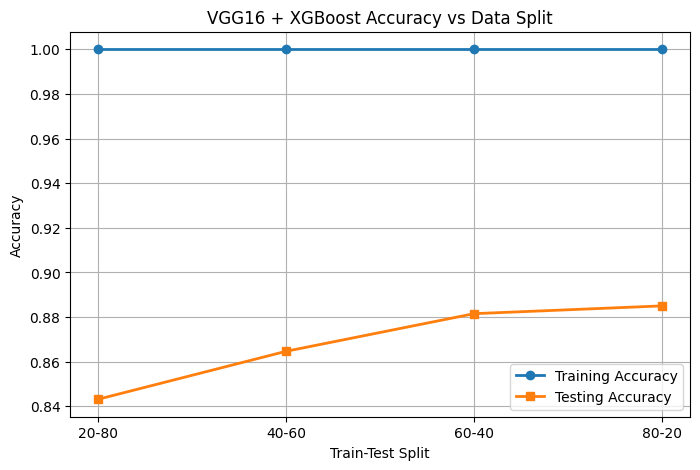

In [ ]:
# ============================================
# CELL 11 — ACCURACY PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    vgg_train_acc,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    vgg_test_acc,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Accuracy")

plt.title("VGG16 + XGBoost Accuracy vs Data Split")

plt.legend()

plt.grid(True)

plt.show()

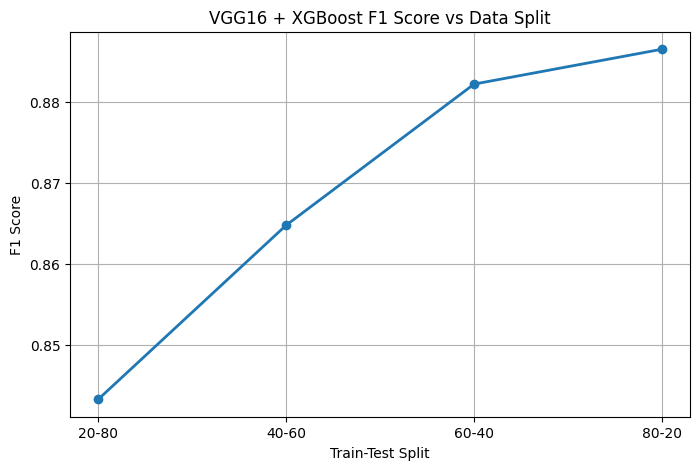

In [ ]:
# ============================================
# CELL 12 — F1 SCORE PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    vgg_f1,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("VGG16 + XGBoost F1 Score vs Data Split")

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# CELL 13 — RESULTS TABLE
# ============================================

results_df = pd.DataFrame({
    'Train-Test Split': labels,
    'Training Accuracy': vgg_train_acc,
    'Testing Accuracy': vgg_test_acc,
    'F1 Score': vgg_f1
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score
0            20-80                1.0          0.843206  0.843349
1            40-60                1.0          0.864692  0.864777
2            60-40                1.0          0.881533  0.882147
3            80-20                1.0          0.885017  0.886440


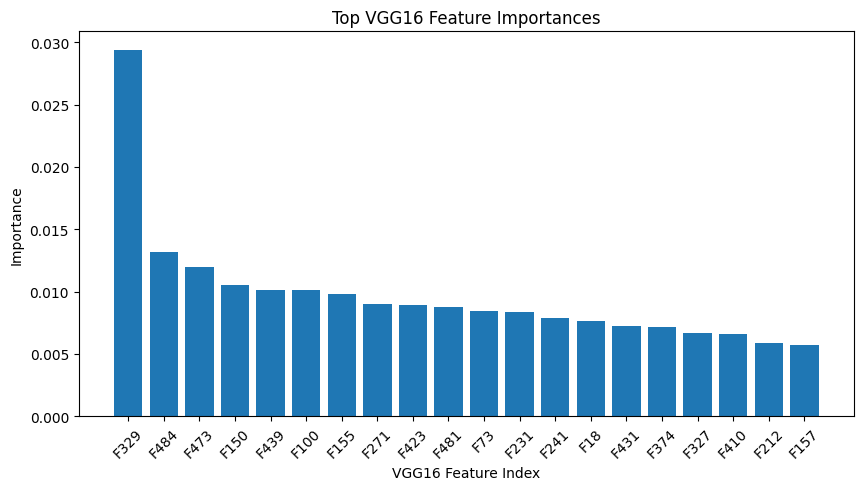

In [ ]:
# ============================================
# CELL 14 — FEATURE IMPORTANCE
# ============================================

importances = xgb_vgg.feature_importances_

top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    importances[top_idx]
)

plt.xticks(
    range(20),
    [f"F{idx+1}" for idx in top_idx],
    rotation=45
)

plt.xlabel("VGG16 Feature Index")

plt.ylabel("Importance")

plt.title("Top VGG16 Feature Importances")

plt.show()

In [ ]:
# ============================================
# CELL 15 — SAMPLE PREDICTIONS
# ============================================

test_path = os.path.join(path, "Testing")

def display_samples_vgg(folder, title, num_samples=9):

    valid_ext = ('.jpg', '.jpeg', '.png')

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    files = files[:num_samples]

    plt.figure(figsize=(12,8))

    for i, filename in enumerate(files):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_rgb = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img_resized = cv2.resize(
            img_rgb,
            (224,224)
        )

        img_input = preprocess_input(
            np.expand_dims(
                img_resized.astype(np.float32),
                axis=0
            )
        )

        feat = extractor.predict(
            img_input,
            verbose=0
        )

        pred = xgb_vgg.predict(feat)[0]

        plt.subplot(3,3,i+1)

        plt.imshow(img_resized)

        plt.title(dec[pred])

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

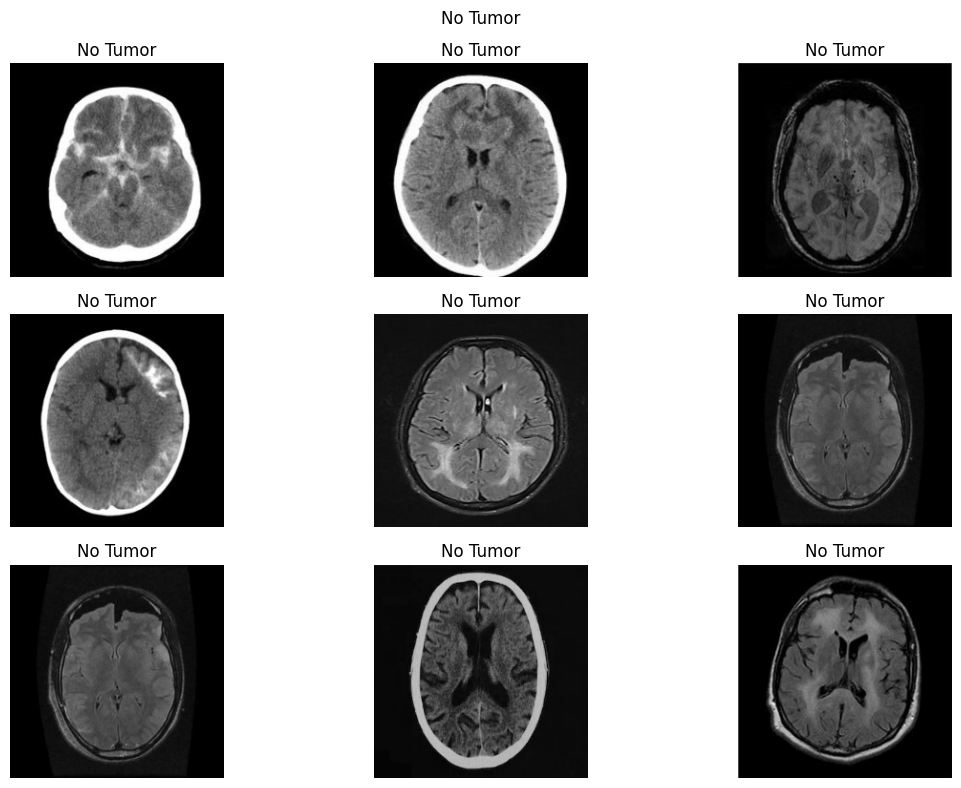

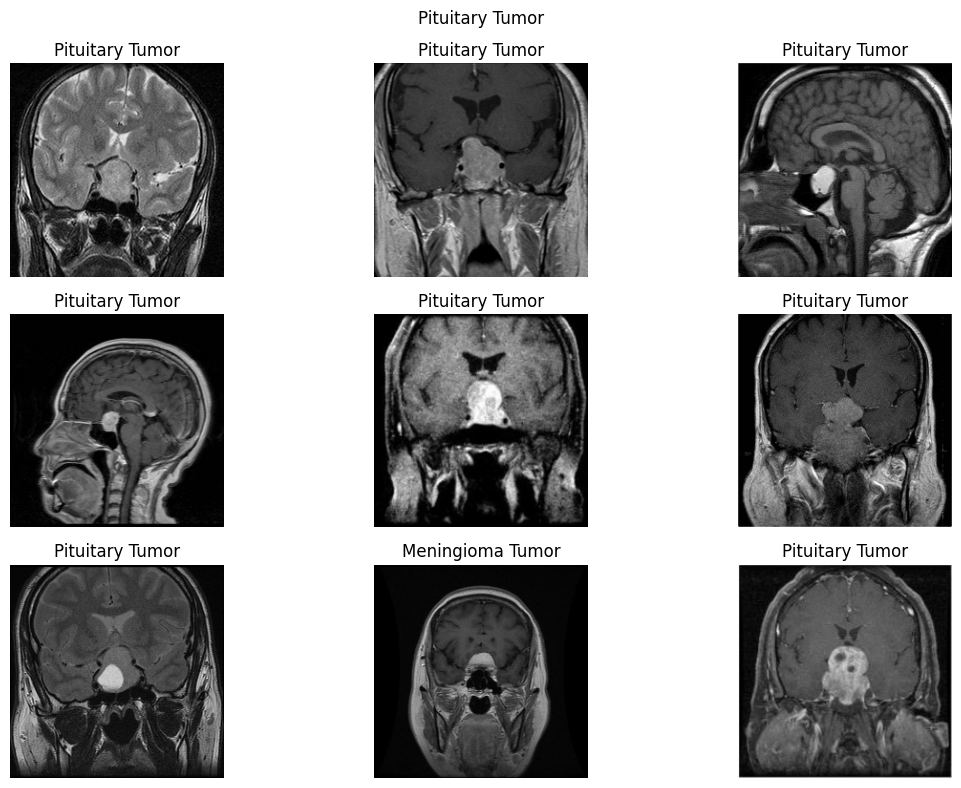

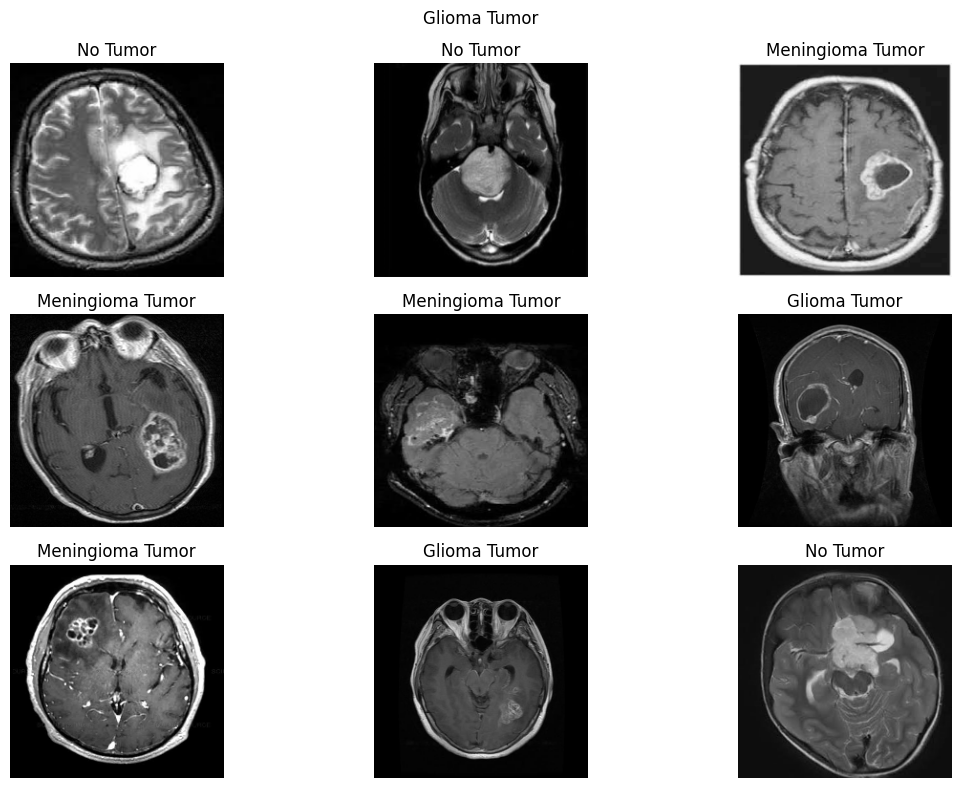

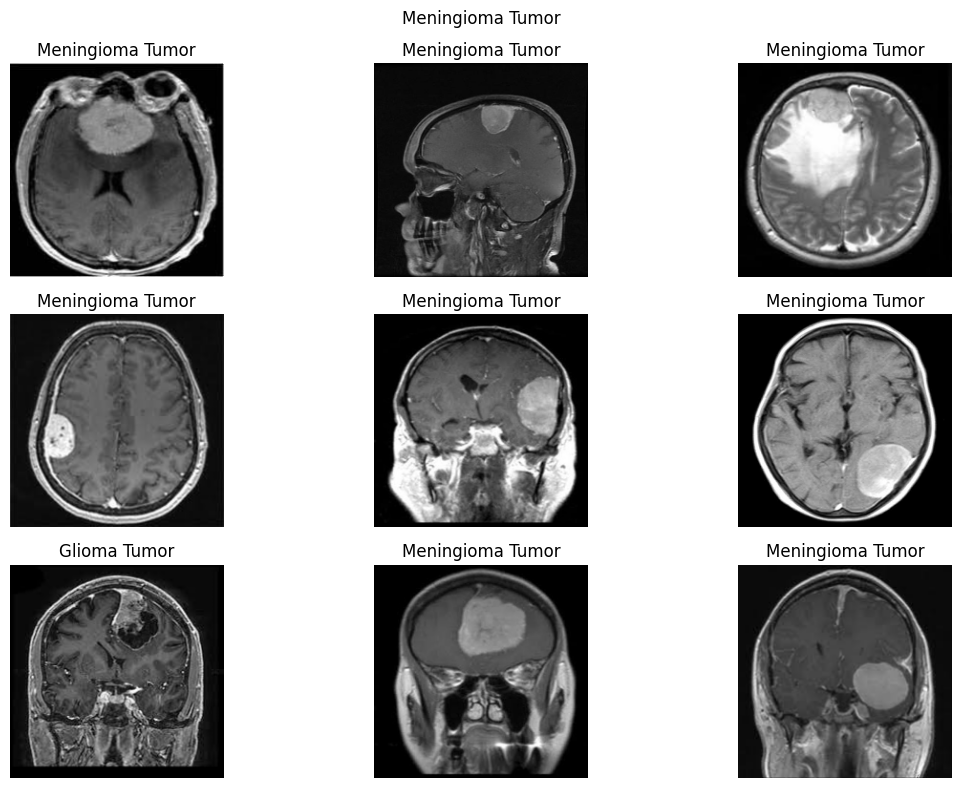

In [ ]:
# ============================================
# CELL 16 — DISPLAY SAMPLE PREDICTIONS
# ============================================

for tumor_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        tumor_folder
    )

    if os.path.isdir(folder_path):

        display_samples_vgg(
            folder_path,
            tumor_folder.replace("_"," ").title()
        )